# <span style="font-weight:bold;color:blue;font-size:1.1em">Day 1: Introduction to Python</span>

In this notebook we will:

- Use two old classics to explore the awesome potential of Python
- See and discuss some early graphs

Throughout the semester, every notebook will contain some embedded statistical task, such as computing a well-known statistic or creating a graphical display.  Even when the stated purpose of the notebook is to learn something specific about Python, that skill will be applied to the completion of some task that is statistical in nature.  This should make it clear that we're not learning Python, *just* to learn Python, but because it IS the primary tool we're using to do our statistics.  Also, by the time we've reached the point in the semester where you know enough Python to shift our focus to statistics, you will already have been exposed to a significant amount of the statistical content of this course.  

**Todays class will end with you completing the First Day Assignment and submitting it.**

#### You may need to uncomment and run the cell below for the notebook to behave properly

In [29]:
# pip install datascience==0.17.5

In [30]:
# Stuff that will appear at the top of notebooks;
# You don't have to understand how this works or change it for now.
from datascience import *
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

from urllib.request import urlopen 
import re
def read_url(url): 
    return re.sub('\\s+', ' ', urlopen(url).read().decode())

## <span style="font-weight:bold;color:blue;font-size:1.1em">1. Read two books, fast!</span>

The code below will read the entire text of
- Huck Finn
- Little Women

into Python's memory so we can analyze it with data science and statistics tools.

In [31]:
huck_finn_url = 'https://www.inferentialthinking.com/data/huck_finn.txt'
huck_finn_text = read_url(huck_finn_url)
huck_finn_chapters = huck_finn_text.split('CHAPTER ')[44:]

little_women_url = 'https://www.inferentialthinking.com/data/little_women.txt'
little_women_text = read_url(little_women_url)
little_women_chapters = little_women_text.split('CHAPTER ')[1:]

In [32]:
Table().with_column('Chapters', huck_finn_chapters).show(5)

Chapters
I. YOU don't know about me without you have read a book ...
II. WE went tiptoeing along a path amongst the trees bac ...
"III. WELL, I got a good going-over in the morning from o ..."
"IV. WELL, three or four months run along, and it was wel ..."
V. I had shut the door to. Then I turned around and ther ...


## <span style="font-weight:bold;color:blue;font-size:1.1em">2. How Often Do Character Names Appear?</span>

In [5]:
np.char.count(huck_finn_chapters, 'Tom')

array([ 6, 24,  5,  0,  0,  0,  2,  2,  0,  0,  2,  3,  1,  0,  0,  0,  3,
        5,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  1,  4, 19, 15,
       14, 18,  9, 32, 11, 11,  8, 30,  6])

In [6]:
np.char.count(huck_finn_chapters, 'Jim')

array([ 0, 16,  0,  8,  0,  0,  0, 22, 11, 19,  4, 20,  9,  6, 16, 28,  0,
       10, 13, 18,  1,  0,  9,  5,  0,  0,  0,  1,  3,  5, 17,  0,  5, 17,
       18, 23,  4, 27, 10, 13,  0, 12,  6])

In [7]:
counts = Table().with_columns([
    'Tom', np.char.count(huck_finn_chapters, 'Tom'),
    'Jim', np.char.count(huck_finn_chapters, 'Jim'),
    'Huck', np.char.count(huck_finn_chapters, 'Huck'),
])
counts.show(5)

Tom,Jim,Huck
6,0,3
24,16,2
5,0,2
0,8,1
0,0,0


Text(0.5, 1.0, 'Cumulative Number of Times Name Appears')

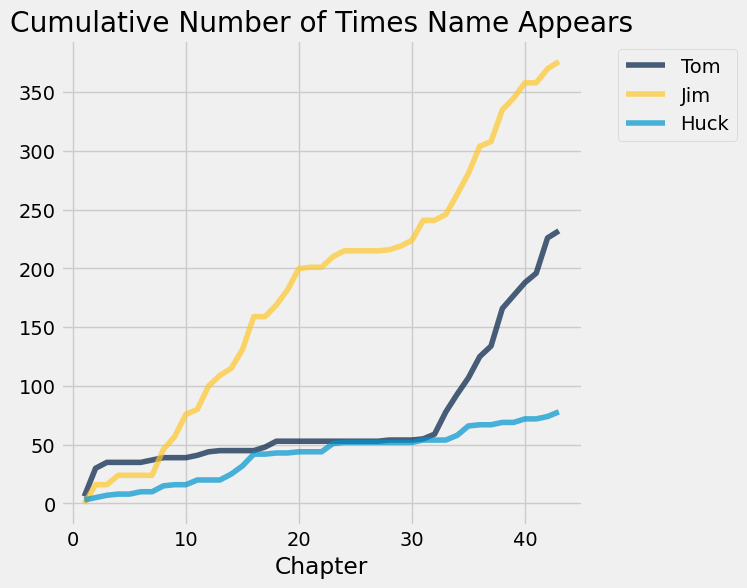

In [9]:
import numpy as np

# Compute cumulative sums for each column using NumPy
cum_tom = np.cumsum(counts.column('Tom'))
cum_jim = np.cumsum(counts.column('Jim'))
cum_huck = np.cumsum(counts.column('Huck'))

# Create the new table with the cumulative counts and chapters
cum_counts = Table().with_columns(
    'Tom', cum_tom,
    'Jim', cum_jim,
    'Huck', cum_huck,
    'Chapter', np.arange(1, 44, 1)
)

# Plot the results
cum_counts.plot(column_for_xticks=3)
plots.title('Cumulative Number of Times Name Appears')

In [10]:
# The chapters of Little Women

Table().with_column('Chapters', little_women_chapters)

Chapters
"ONE PLAYING PILGRIMS ""Christmas won't be Christmas witho ..."
TWO A MERRY CHRISTMAS Jo was the first to wake in the gr ...
"THREE THE LAURENCE BOY ""Jo! Jo! Where are you?"" cried Me ..."
"FOUR BURDENS ""Oh, dear, how hard it does seem to take up ..."
"FIVE BEING NEIGHBORLY ""What in the world are you going t ..."
SIX BETH FINDS THE PALACE BEAUTIFUL The big house did pr ...
"SEVEN AMY'S VALLEY OF HUMILIATION ""That boy is a perfect ..."
"EIGHT JO MEETS APOLLYON ""Girls, where are you going?"" as ..."
"NINE MEG GOES TO VANITY FAIR ""I do think it was the most ..."
"TEN THE P.C. AND P.O. As spring came on, a new set of am ..."


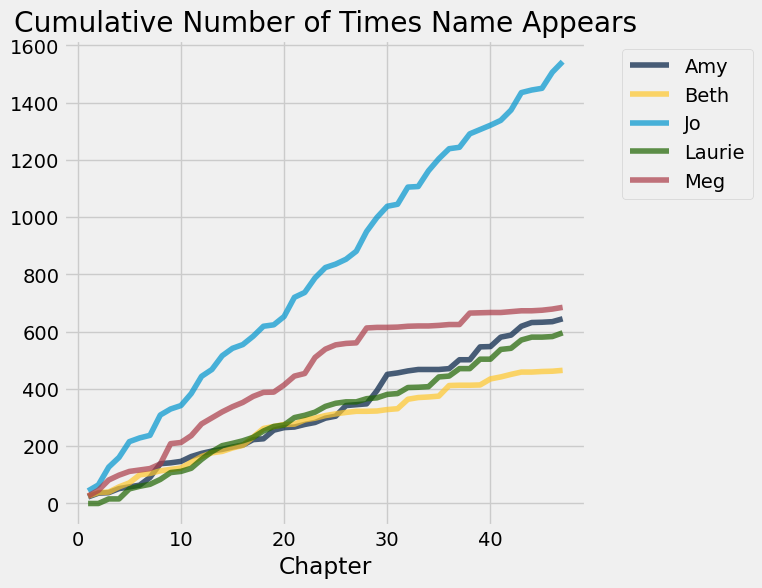

In [20]:
# Counts of names in the chapters of Little Women

people = ['Amy', 'Beth', 'Jo', 'Laurie', 'Meg']
cum_amy = np.cumsum(counts.column('Amy'))
cum_beth = np.cumsum(counts.column('Beth'))
cum_jo = np.cumsum(counts.column('Jo'))
cum_meg = np.cumsum(counts.column('Meg'))
cum_laurie = np.cumsum(counts.column('Laurie'))

cum_counts = Table().with_columns(
    'Amy', cum_amy,
    'Beth', cum_beth,
    'Jo', cum_jo,
    'Laurie', cum_laurie,
    'Beth', cum_beth,
    'Meg', cum_meg,
    'Chapter', np.arange(1, 48, 1)
)

cum_counts.plot(column_for_xticks=5)
plots.title('Cumulative Number of Times Name Appears');

In [21]:
# In each chapter, count the number of all characters;
# call this the "length" of the chapter.
# Also count the number of periods.

chars_periods_hf = Table().with_columns([
        'HF Chapter Length', [len(s) for s in huck_finn_chapters],
        'Number of Periods', np.char.count(huck_finn_chapters, '.')
    ])
chars_periods_lw = Table().with_columns([
        'LW Chapter Length', [len(s) for s in little_women_chapters],
        'Number of Periods', np.char.count(little_women_chapters, '.')
    ])

## <span style="font-weight:bold;color:blue;font-size:1.1em">3. Other Tools We can Use</span>

In [22]:
# The counts for Huckleberry Finn

chars_periods_hf

HF Chapter Length,Number of Periods
7026,66
11982,117
8529,72
6799,84
8166,91
14550,125
13218,127
22208,249
8081,71
7036,70


In [23]:
# The counts for Little Women

chars_periods_lw

LW Chapter Length,Number of Periods
21759,189
22148,188
20558,231
25526,195
23395,255
14622,140
14431,131
22476,214
33767,337
18508,185


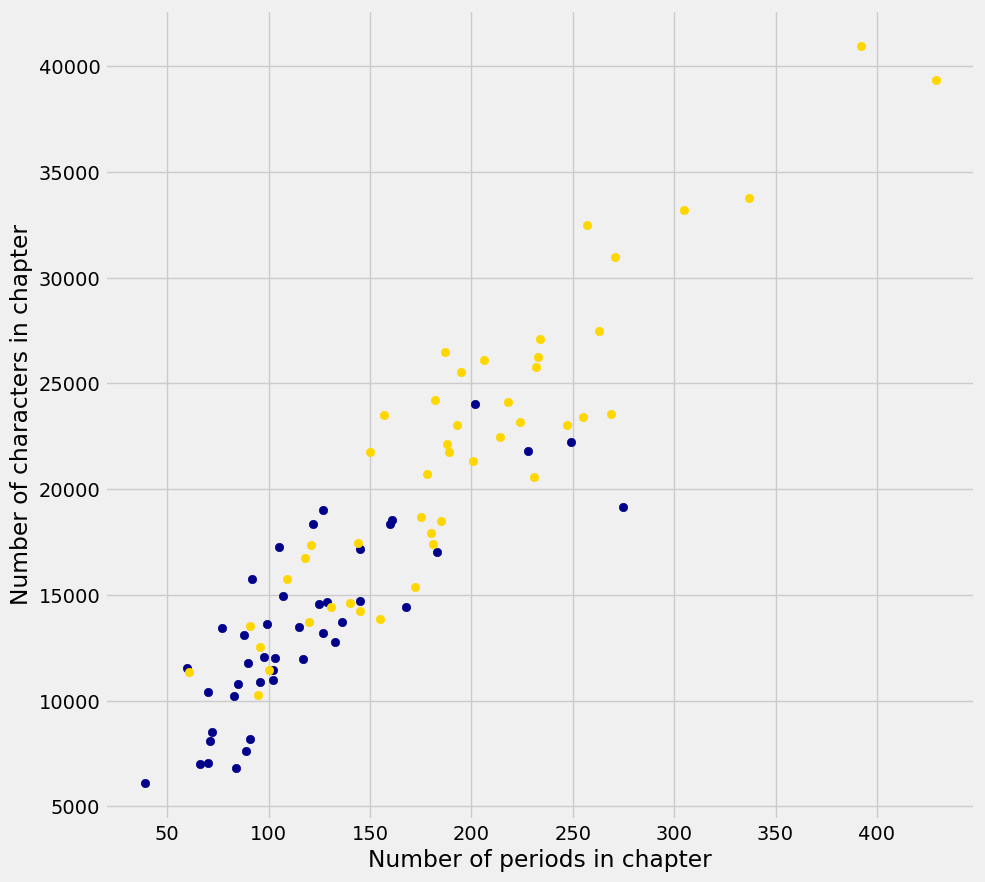

In [24]:
plots.figure(figsize=(10,10))
plots.scatter(chars_periods_hf[1], chars_periods_hf[0], color='darkblue')
plots.scatter(chars_periods_lw[1], chars_periods_lw[0], color='gold')
plots.xlabel('Number of periods in chapter')
plots.ylabel('Number of characters in chapter');

In [25]:
cum_counts.where("Chapter", 47).drop("Chapter")

Amy,Beth,Jo,Laurie,Meg
645,465,1543,596,685


In [26]:
Name_totals = Table().with_columns("Names", make_array("Amy", "Beth", "Jo", "Laurie", "Meg"), 
                                   "Total", make_array(645, 465, 1543, 596, 685))

Name_totals

Names,Total
Amy,645
Beth,465
Jo,1543
Laurie,596
Meg,685


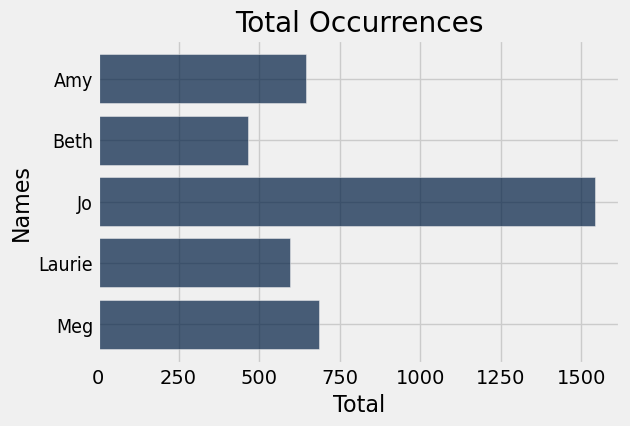

In [27]:
Name_totals.barh("Names")
plots.title("Total Occurrences");

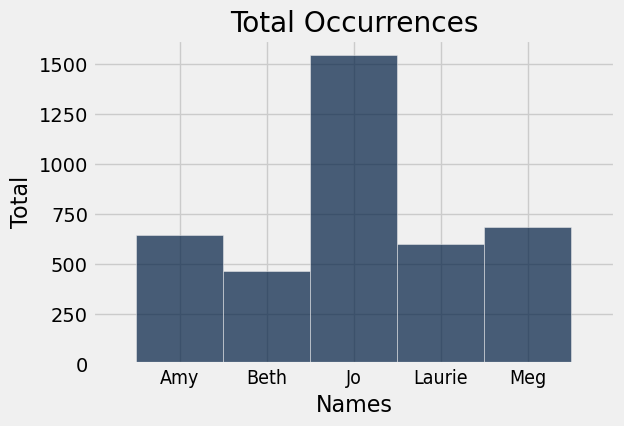

In [28]:
Name_totals.bar("Names")
plots.title("Total Occurrences");

## First Day Assignment

Find and open the First Day Assignment.  Edit the notebook to complete the assignment and submit it via D2L when complete.